In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import median_survival_times
from lifelines.plotting import add_at_risk_counts

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

DATA_FILE = (
    PROJECT_DIR
    / "processed_data"
    / "metabric_survival_cohort.csv"
)

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1981, 37)


,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,SEX,INTCLUST,AGE_AT_DIAGNOSIS,OS_MONTHS,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS,EVENT
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.500000,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred,MB-0000,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Negative,Primary,22.0,2.0,0.000000,0
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.633333,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred,MB-0002,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Positive,Primary,10.0,1.0,2.615035,0
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.700000,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred,MB-0005,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2.0,IDC,Positive,Primary,15.0,2.0,2.615035,1
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred,MB-0006,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2.0,MDLC,Positive,Primary,25.0,2.0,1.307518,0
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.366667,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred,MB-0008,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3.0,MDLC,Positive,Primary,40.0,2.0,2.615035,1


In [5]:

print("Survival time summary:")

display(df["OS_MONTHS"].describe())

print("\nEvent distribution:")

print(df["EVENT"].value_counts())

print("\nMissing survival values:")

print(
    df[["OS_MONTHS", "EVENT"]]
    .isna()
    .sum()
)

print("\nUnique event values:")

print(df["EVENT"].unique())

Survival time summary:


count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: OS_MONTHS, dtype: float64


Event distribution:
EVENT
1    1144
0     837
Name: count, dtype: int64

Missing survival values:
OS_MONTHS    0
EVENT        0
dtype: int64

Unique event values:
[0 1]


In [7]:

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df["OS_MONTHS"],
    event_observed=df["EVENT"],
    label="Overall Survival"
)

print("Kaplan-Meier model fitted successfully!")

display(kmf.survival_function_.head(10))

Kaplan-Meier model fitted successfully!


,Overall Survival
timeline,
0.000000,1.000000
0.100000,0.999495
0.766667,0.999495
1.233333,0.999495
1.266667,0.999495
1.433333,0.999495
1.766667,0.999495
2.000000,0.999495
2.300000,0.998988


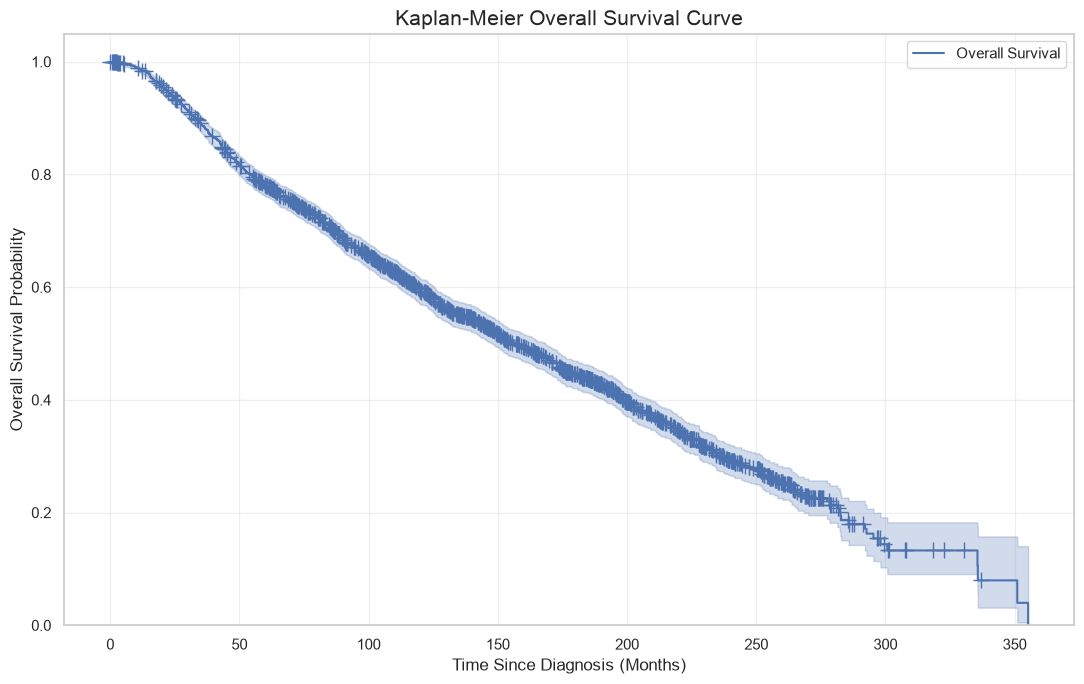

In [9]:

fig, ax = plt.subplots(figsize=(11, 7))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,
    show_censors=True
)

ax.set_title(
    "Kaplan-Meier Overall Survival Curve",
    fontsize=15
)

ax.set_xlabel("Time Since Diagnosis (Months)")

ax.set_ylabel("Overall Survival Probability")

ax.set_ylim(0, 1.05)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [11]:

time_points = [12, 36, 60, 120]

survival_probabilities = kmf.survival_function_at_times(
    time_points
)

survival_results = pd.DataFrame({
    "Time_Months": time_points,
    "Time_Years": [1, 3, 5, 10],
    "Survival_Probability": survival_probabilities.values
})

survival_results["Survival_Percentage"] = (
    survival_results["Survival_Probability"] * 100
)

display(survival_results.round(3))

,Time_Months,Time_Years,Survival_Probability,Survival_Percentage
0,12,1,0.985,98.475
1,36,3,0.886,88.585
2,60,5,0.780,78.019
3,120,10,0.593,59.265


In [13]:

median_survival = kmf.median_survival_time_

print(
    "Median overall survival:",
    round(median_survival, 2),
    "months"
)

print(
    "Median overall survival:",
    round(median_survival / 12, 2),
    "years"
)

Median overall survival: 156.33 months
Median overall survival: 13.03 years


In [15]:

df["AGE_GROUP"] = np.where(
    df["AGE_AT_DIAGNOSIS"] < 60,
    "Under 60",
    "60 and Above"
)

print(df["AGE_GROUP"].value_counts())

display(
    df[
        ["AGE_AT_DIAGNOSIS", "AGE_GROUP"]
    ].head(10)
)

AGE_GROUP
60 and Above    1108
Under 60         873
Name: count, dtype: int64


,AGE_AT_DIAGNOSIS,AGE_GROUP
0,75.65,60 and Above
1,43.19,Under 60
2,48.87,Under 60
3,47.68,Under 60
4,76.97,60 and Above
5,78.77,60 and Above
6,56.45,Under 60
7,70.00,60 and Above
8,89.08,60 and Above
9,86.41,60 and Above


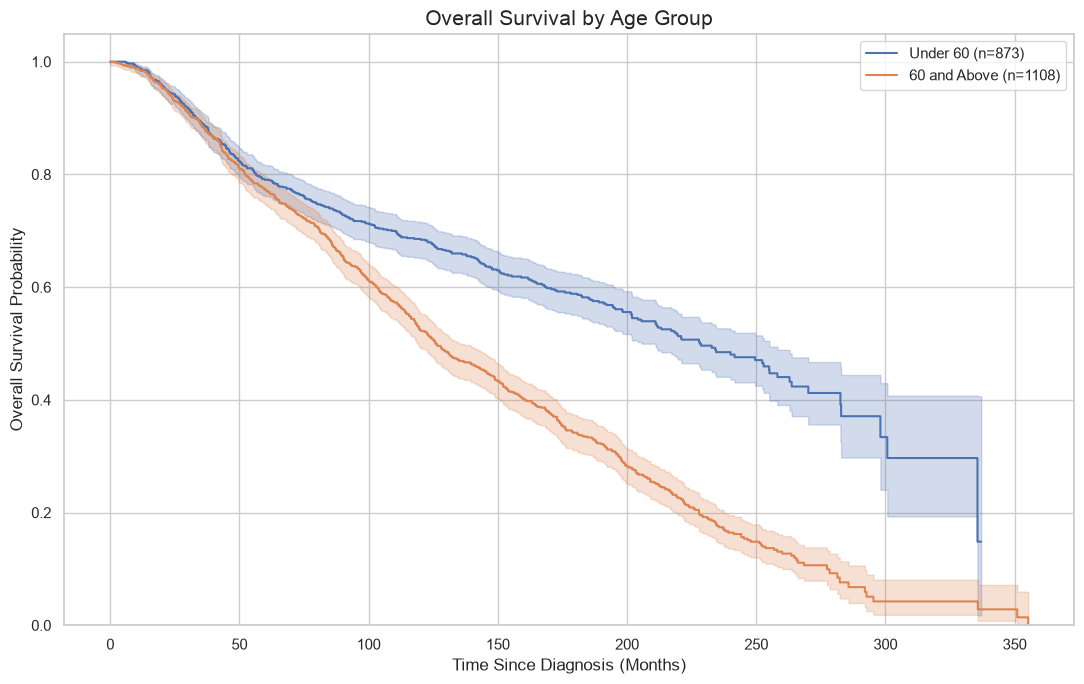

In [17]:

fig, ax = plt.subplots(figsize=(11, 7))

kmf_age = {}

for group in ["Under 60", "60 and Above"]:

    subset = df[df["AGE_GROUP"] == group]

    model = KaplanMeierFitter()

    model.fit(
        durations=subset["OS_MONTHS"],
        event_observed=subset["EVENT"],
        label=f"{group} (n={len(subset)})"
    )

    model.plot_survival_function(
        ax=ax,
        ci_show=True
    )

    kmf_age[group] = model

ax.set_title(
    "Overall Survival by Age Group",
    fontsize=15
)

ax.set_xlabel("Time Since Diagnosis (Months)")

ax.set_ylabel("Overall Survival Probability")

ax.set_ylim(0, 1.05)

ax.legend()

plt.tight_layout()

plt.show()

In [19]:

younger = df[
    df["AGE_GROUP"] == "Under 60"
]

older = df[
    df["AGE_GROUP"] == "60 and Above"
]

age_logrank = logrank_test(
    younger["OS_MONTHS"],
    older["OS_MONTHS"],
    event_observed_A=younger["EVENT"],
    event_observed_B=older["EVENT"]
)

print("Log-rank test: Age groups")

print(
    "Test statistic:",
    age_logrank.test_statistic
)

print(
    "P-value:",
    age_logrank.p_value
)

age_logrank.print_summary()

Log-rank test: Age groups
Test statistic: 112.56220651452837
P-value: 2.690884626716792e-26


In [21]:

stage_df = df.dropna(
    subset=["TUMOR_STAGE"]
).copy()

stage_df["TUMOR_STAGE"] = (
    stage_df["TUMOR_STAGE"].astype(int)
)

print("Patients with known tumor stage:")

print(len(stage_df))

print("\nTumor stage distribution:")

print(
    stage_df["TUMOR_STAGE"]
    .value_counts()
    .sort_index()
)

Patients with known tumor stage:
1466

Tumor stage distribution:
TUMOR_STAGE
0     12
1    501
2    825
3    118
4     10
Name: count, dtype: int64


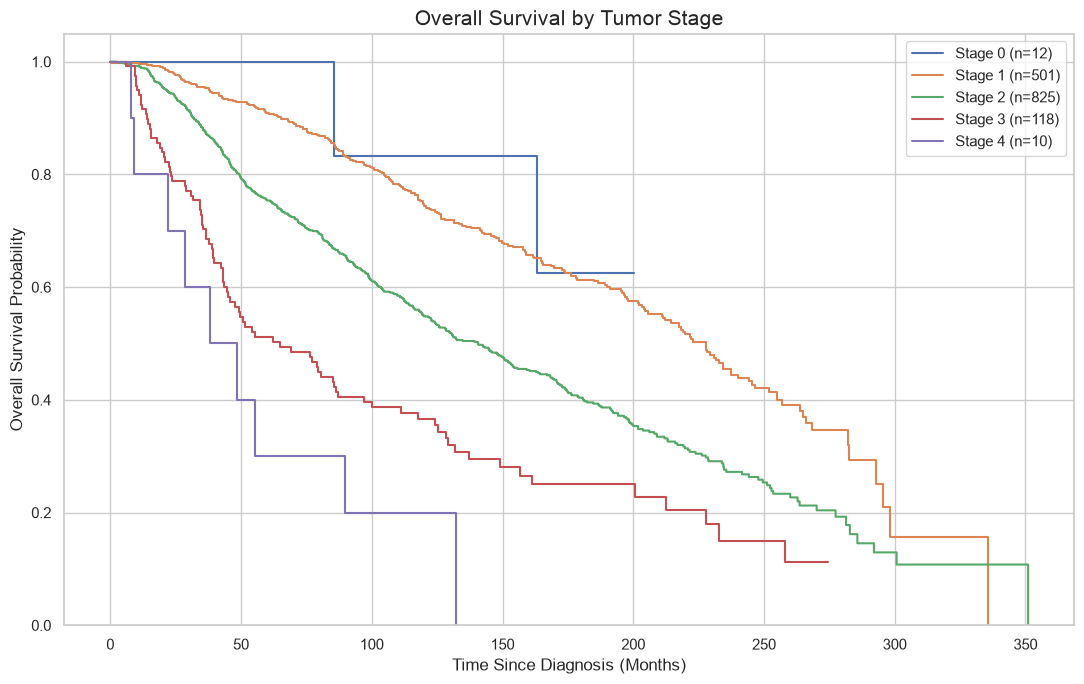

In [23]:

fig, ax = plt.subplots(figsize=(11, 7))

kmf_stage = {}

for stage in sorted(
    stage_df["TUMOR_STAGE"].unique()
):

    subset = stage_df[
        stage_df["TUMOR_STAGE"] == stage
    ]

    model = KaplanMeierFitter()

    model.fit(
        durations=subset["OS_MONTHS"],
        event_observed=subset["EVENT"],
        label=f"Stage {stage} (n={len(subset)})"
    )

    model.plot_survival_function(
        ax=ax,
        ci_show=False
    )

    kmf_stage[stage] = model

ax.set_title(
    "Overall Survival by Tumor Stage",
    fontsize=15
)

ax.set_xlabel("Time Since Diagnosis (Months)")

ax.set_ylabel("Overall Survival Probability")

ax.set_ylim(0, 1.05)

ax.legend()

plt.tight_layout()

plt.show()

In [25]:

stage_logrank = multivariate_logrank_test(
    event_durations=stage_df["OS_MONTHS"],
    groups=stage_df["TUMOR_STAGE"],
    event_observed=stage_df["EVENT"]
)

print("Log-rank test: Tumor stages")

print(
    "Test statistic:",
    stage_logrank.test_statistic
)

print(
    "P-value:",
    stage_logrank.p_value
)

stage_logrank.print_summary()

Log-rank test: Tumor stages
Test statistic: 128.22121923446934
P-value: 9.349056262284235e-27


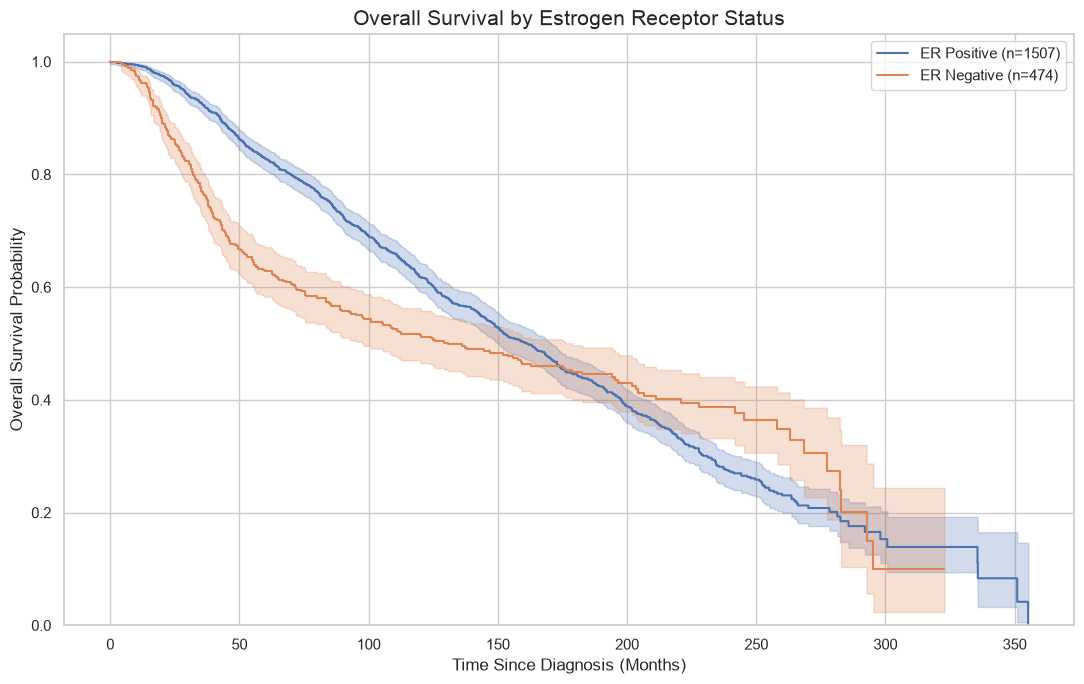

In [27]:

er_df = df.dropna(
    subset=["ER_STATUS"]
).copy()

fig, ax = plt.subplots(figsize=(11, 7))

kmf_er = {}

for status in ["Positive", "Negative"]:

    subset = er_df[
        er_df["ER_STATUS"] == status
    ]

    model = KaplanMeierFitter()

    model.fit(
        durations=subset["OS_MONTHS"],
        event_observed=subset["EVENT"],
        label=f"ER {status} (n={len(subset)})"
    )

    model.plot_survival_function(
        ax=ax,
        ci_show=True
    )

    kmf_er[status] = model

ax.set_title(
    "Overall Survival by Estrogen Receptor Status",
    fontsize=15
)

ax.set_xlabel("Time Since Diagnosis (Months)")

ax.set_ylabel("Overall Survival Probability")

ax.set_ylim(0, 1.05)

ax.legend()

plt.tight_layout()

plt.show()

In [29]:

er_positive = er_df[
    er_df["ER_STATUS"] == "Positive"
]

er_negative = er_df[
    er_df["ER_STATUS"] == "Negative"
]

er_logrank = logrank_test(
    er_positive["OS_MONTHS"],
    er_negative["OS_MONTHS"],
    event_observed_A=er_positive["EVENT"],
    event_observed_B=er_negative["EVENT"]
)

print("Log-rank test: ER status")

print(
    "Test statistic:",
    er_logrank.test_statistic
)

print(
    "P-value:",
    er_logrank.p_value
)

er_logrank.print_summary()

Log-rank test: ER status
Test statistic: 4.442896373103488
P-value: 0.03504674239976644


In [31]:

summary_results = []

models = {
    "Overall": kmf,
    "Age Under 60": kmf_age["Under 60"],
    "Age 60 and Above": kmf_age["60 and Above"],
    "ER Positive": kmf_er["Positive"],
    "ER Negative": kmf_er["Negative"]
}

for group, model in models.items():

    survival_5yr = float(
        model.predict(60)
    )

    survival_10yr = float(
        model.predict(120)
    )

    summary_results.append({
        "Group": group,
        "Patients": len(model.durations),
        "Events": int(model.event_observed.sum()),
        "5_Year_Survival_Percent": survival_5yr * 100,
        "10_Year_Survival_Percent": survival_10yr * 100,
        "Median_Survival_Months": model.median_survival_time_
    })

summary_df = pd.DataFrame(
    summary_results
)

display(
    summary_df.round(2)
)

,Group,Patients,Events,5_Year_Survival_Percent,10_Year_Survival_Percent,Median_Survival_Months
0,Overall,1981,1144,78.02,59.27,156.33
1,Age Under 60,873,369,79.05,68.55,228.10
2,Age 60 and Above,1108,775,77.22,52.30,125.90
3,ER Positive,1507,882,82.76,61.73,161.13
4,ER Negative,474,262,62.86,51.49,130.87


In [33]:

RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_df.to_csv(
    RESULTS_DIR / "kaplan_meier_summary.csv",
    index=False
)

logrank_results = pd.DataFrame({
    "Comparison": [
        "Age Groups",
        "Tumor Stages",
        "ER Status"
    ],
    "Test_Statistic": [
        age_logrank.test_statistic,
        stage_logrank.test_statistic,
        er_logrank.test_statistic
    ],
    "P_Value": [
        age_logrank.p_value,
        stage_logrank.p_value,
        er_logrank.p_value
    ]
})

logrank_results.to_csv(
    RESULTS_DIR / "logrank_test_results.csv",
    index=False
)

display(logrank_results)

print("Research results saved successfully!")

,Comparison,Test_Statistic,P_Value
0,Age Groups,112.562207,2.690885e-26
1,Tumor Stages,128.221219,9.349056e-27
2,ER Status,4.442896,3.504674e-02


Research results saved successfully!
